In [1]:
# Parameters
BATCH_MODE = True


# Verbal Duel: Barbie vs Shrek's Donkey
## Introduction - barbie schreck

**Navigation** : [Index](../README.md)

This notebook covers the main concepts and techniques of barbie schreck. The learning objectives include understanding the fundamentals, putting them into practice through exercises, and analyzing results.

**Prerequisites** : basic knowledge of Python and algorithms.

Notebook using Semantic Kernel for a constrained debate with image generation

In [2]:
# Import guards - availability flags for external dependencies

try:
    from IPython.display import display, Audio, Image as IPImage
    IPYTHON_AVAILABLE = True
except ImportError:
    IPYTHON_AVAILABLE = False
    print(f'  IPython non disponible - certaines fonctionnalites seront limitees')

try:
    from dotenv import load_dotenv
    DOTENV_AVAILABLE = True
except ImportError:
    DOTENV_AVAILABLE = False
    print(f'  dotenv non disponible - certaines fonctionnalites seront limitees')

try:
    import semantic_kernel
    SEMANTIC_KERNEL_AVAILABLE = True
except ImportError:
    SEMANTIC_KERNEL_AVAILABLE = False
    print(f'  semantic_kernel non disponible - certaines fonctionnalites seront limitees')


## Initial configuration
Loading environment variables and initializing services

In [3]:
import os
import random
import logging
from dotenv import load_dotenv
from semantic_kernel import Kernel
from semantic_kernel.agents import ChatCompletionAgent, AgentGroupChat
from semantic_kernel.connectors.ai.open_ai import OpenAIChatCompletion
from semantic_kernel.connectors.ai.open_ai.services.open_ai_text_to_image import OpenAITextToImage
from semantic_kernel.functions import kernel_function, KernelArguments
from semantic_kernel.contents import ChatMessageContent, AuthorRole

load_dotenv()
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger('BarbieVsAne')
print("Imports et configuration OK")


Imports et configuration OK


## Definition of Linguistic Constraints
Random selection of a constraint for the debate

In [4]:
CONTRAINTES = [
    ("Rime", "Chaque réplique doit contenir une rime parfaite"),
    ("Shakespeare", "Imiter le style théâtral de Shakespeare"),
    ("Chanson", "Répondre sur l'air de 'I'm a Believer'")
]

contrainte_choisie = random.choice(CONTRAINTES)
print(f"Contrainte choisie : {contrainte_choisie[0]}")
print("Contraintes de debate definies")


Contrainte choisie : Rime
Contraintes de debate definies


### Exercise 1: Adding custom linguistic constraints

The list `CONTRAINTES` currently contains three styles (Rhyme, Shakespeare, Song). The objective is to enrich this list with new original constraints to vary the debates.

**Objective**: add at least two new constraints to the list, for example a "Japanese Haiku" style (3 lines, 5-7-5 syllables) or "Python Code" (respond using Python syntax).

**Hints**:
- # Step 1: Define the name and description of each new constraint
- # Step 2: Add the tuples `(nom, description)` to the list `CONTRAINTES`
- # Hint: respect the existing format `("Nom", "Description de la regle")`

In [5]:
# Exercice 1 : Ajout de contraintes linguistiques personnalisees
# TODO etudiant : ajouter de nouvelles contraintes a la liste

NOUVELLES_CONTRAINTES = []  # Etape 1 : definir les nouvelles contraintes

# Etape 2 : les ajouter a CONTRAINTES
# CONTRAINTES.extend(NOUVELLES_CONTRAINTES)

print("Exercice a completer : nouvelles contraintes")

Exercice a completer : nouvelles contraintes


## Kernel creation
Initializing OpenAI services for chat and images

In [6]:
def create_kernel():
    kernel = Kernel()
    kernel.add_service(OpenAIChatCompletion(
        service_id="chat",
         ai_model_id=os.getenv("OPENAI_CHAT_MODEL_ID"),
        api_key=os.getenv("OPENAI_API_KEY")
    ))
    kernel.add_service(OpenAITextToImage(
        service_id="dalle",
        ai_model_id="gpt-image-1",
        api_key=os.getenv("OPENAI_API_KEY")
    ))
    return kernel

print("Fonction create_kernel définie")
print("Fonction create_kernel definie")


Fonction create_kernel définie
Fonction create_kernel definie


## Image generation plugin
Implementation of the illustration creation feature

In [7]:
class ImagePlugin:
    def __init__(self, kernel):
        self.text_to_image = kernel.get_service("dalle", OpenAITextToImage)

    @kernel_function(name="generate_image", description="Genere une image via DALL-E")
    async def generate(self, context: str) -> str:
        try:
            response = await self.text_to_image.generate_image(
                description=f"Style cartoon comique - {context}",
                width=1024,
                height=1024
            )
            return str(response)
        except Exception as e:
            logger.error(f"Erreur generation image: {e}")
            return ""
print("Classe ImagePlugin définie")
print("Debat configure")
print("Classe ImagePlugin definie")


Classe ImagePlugin définie
Debat configure
Classe ImagePlugin definie


## Agent configuration
Creating characters with their specific instructions

In [8]:
# Création des kernels séparés
kernel_barbie = create_kernel()
kernel_ane = create_kernel()

image_Plugin = ImagePlugin(kernel_ane)
# Ajout du plugin uniquement à l'Âne
kernel_ane.add_plugin(image_Plugin, plugin_name="image_gen")




barbie = ChatCompletionAgent(
    kernel=kernel_barbie,
    name="Barbie",
    instructions=f"""
    Tu es Barbie. Défends des positions optimistes avec élégance.
    Contrainte obligatoire : {contrainte_choisie[1]}
    """
)

ane = ChatCompletionAgent(
    kernel=kernel_ane,
    name="Ane_Shrek",
    instructions=f"""
    Tu es l'Âne de Shrek. Utilise l'humour absurde et décalé.
    Contrainte obligatoire : {contrainte_choisie[1]}
    """
)

print("Kernels et agents Barbie/Ane créés")
print("Kernels et agents Barbie/Ane crees")


Kernels et agents Barbie/Ane créés
Kernels et agents Barbie/Ane crees


### Exercise 2: Creating a third agent

The debate currently pits Barbie against Shrek's Donkey. The objective is to add a **third character** to the debate: a **Referee** who comments on the performance of the two duelists at each turn.

**Objective**: create a `ChatCompletionAgent` agent named "Arbitre" with a separate kernel and system instructions asking it to judge the quality of the replies (constraint compliance, creativity, humor).

**Hints**:
- # Step 1: Create a dedicated kernel for the Referee with `create_kernel()`
- # Step 2: Define the Referee's instructions (role, expected behavior)
- # Hint: draw inspiration from Barbie's and the Donkey's instructions for the prompt format

In [9]:
# Exercice 2 : Creation d'un troisieme agent (Arbitre)
# TODO etudiant : creer le kernel et l'agent Arbitre

kernel_arbitre = None  # Etape 1 : creer un kernel avec create_kernel()
ARBITRE_INSTRUCTIONS = ""  # Etape 2 : definir les instructions de l'arbitre

arbitre = None  # TODO etudiant : creer le ChatCompletionAgent

print("Exercice a completer : agent Arbitre")

Exercice a completer : agent Arbitre


## Termination strategy
Stopping the debate after 5 exchanges

In [10]:
# %% [code]
from typing import ClassVar
from semantic_kernel.agents.strategies.termination.termination_strategy import TerminationStrategy

class DebateTerminationStrategy(TerminationStrategy):
    MAX_TURNS: ClassVar[int] = 5  # Annotation correcte avec ClassVar
    
    async def should_terminate(self, agent, history, cancellation_token=None) -> bool:
        return len(history) >= self.MAX_TURNS
print("Stratégie de terminaison du débat configurée")
print("Fonction create_kernel definie")
print("Strategie de terminaison du debate configuree")


Stratégie de terminaison du débat configurée
Fonction create_kernel definie
Strategie de terminaison du debate configuree


## Launching the debate
Running the conversation with image generation

INFO:BarbieVsAne:Contrainte active : Rime


INFO:semantic_kernel.agents.group_chat.agent_chat:Adding `1` agent chat messages


INFO:semantic_kernel.agents.strategies.selection.sequential_selection_strategy:Selected agent at index 0 (ID: 7761ba9d-fa3a-4a42-958d-b11e33481f51, name: Barbie)


INFO:semantic_kernel.agents.group_chat.agent_chat:Invoking agent Barbie


INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


...


Ane_Shrek: Je débarque en braillant, je veux du bruit et du **fromage**,  
Duel verbal en plein marais : prépare ta langue au **fromage**.


INFO:httpx:HTTP Request: POST https://api.openai.com/v1/images/generations "HTTP/1.1 200 OK"


INFO:semantic_kernel.connectors.ai.open_ai.services.open_ai_handler:OpenAI image usage: Usage(input_tokens=46, input_tokens_details=UsageInputTokensDetails(image_tokens=0, text_tokens=46), output_tokens=4160, total_tokens=4206, output_tokens_details=UsageOutputTokensDetails(image_tokens=4160, text_tokens=0))


INFO:semantic_kernel.functions.kernel_function:Function image_gen-generate_image succeeded.


INFO:semantic_kernel.functions.kernel_function:Function completed. Duration: 37.479540s


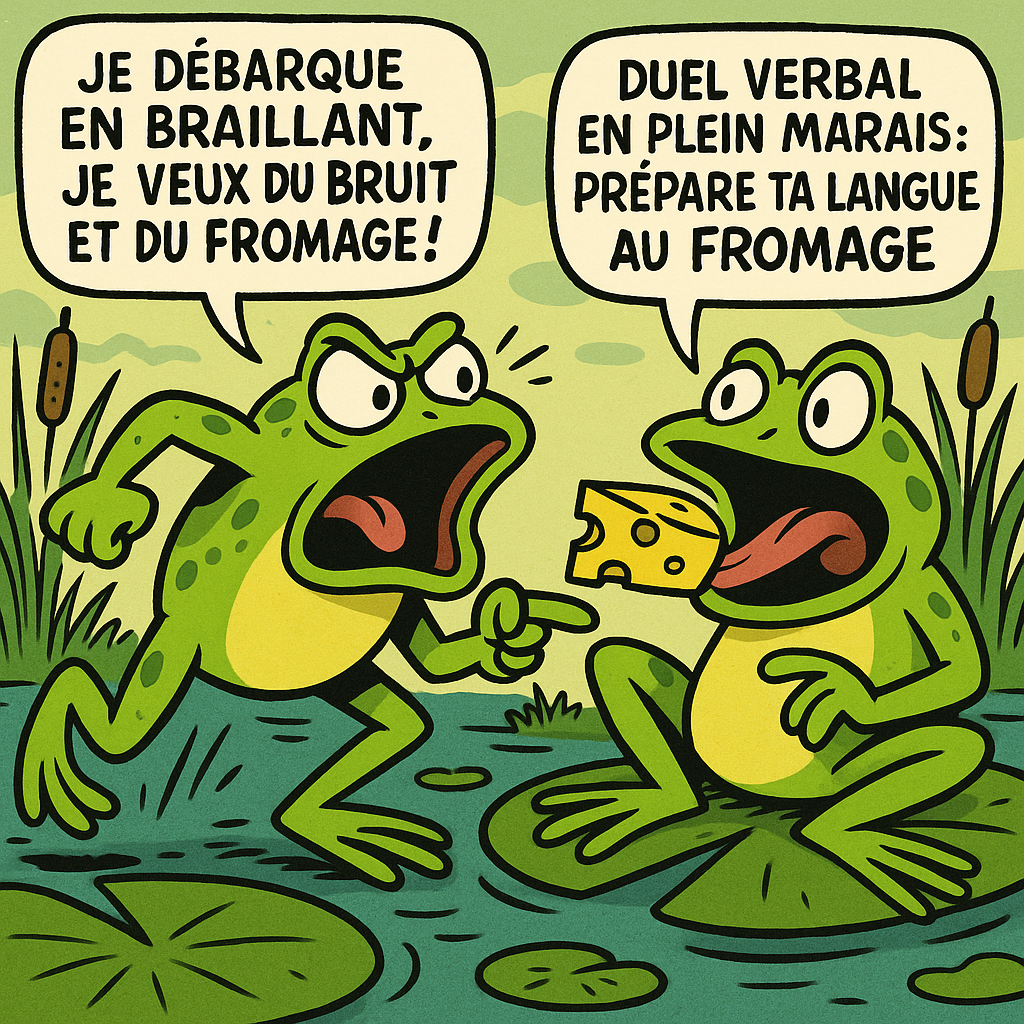

INFO:semantic_kernel.agents.strategies.selection.sequential_selection_strategy:Selected agent at index 0 (ID: 7761ba9d-fa3a-4a42-958d-b11e33481f51, name: Barbie)


INFO:semantic_kernel.agents.group_chat.agent_chat:Invoking agent Barbie


INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


INFO:semantic_kernel.connectors.ai.open_ai.services.open_ai_handler:OpenAI usage: CompletionUsage(completion_tokens=40, prompt_tokens=238, total_tokens=278, completion_tokens_details=CompletionTokensDetails(accepted_prediction_tokens=0, audio_tokens=0, reasoning_tokens=0, rejected_prediction_tokens=0), prompt_tokens_details=PromptTokensDetails(audio_tokens=0, cached_tokens=0))


INFO:semantic_kernel.agents.strategies.selection.sequential_selection_strategy:Selected agent at index 1 (ID: c245c475-6c4d-444c-a6fa-a0a8e2718368, name: Ane_Shrek)


...


Ane_Shrek: Je débarque en trombe, j’te défie sans sommation, c’est la **bagarre**,  
Crache ta meilleure vanne, moi j’te réponds au galop, c’est la **bagarre**.


INFO:httpx:HTTP Request: POST https://api.openai.com/v1/images/generations "HTTP/1.1 200 OK"


INFO:semantic_kernel.connectors.ai.open_ai.services.open_ai_handler:OpenAI image usage: Usage(input_tokens=60, input_tokens_details=UsageInputTokensDetails(image_tokens=0, text_tokens=60), output_tokens=4160, total_tokens=4220, output_tokens_details=UsageOutputTokensDetails(image_tokens=4160, text_tokens=0))


INFO:semantic_kernel.functions.kernel_function:Function image_gen-generate_image succeeded.


INFO:semantic_kernel.functions.kernel_function:Function completed. Duration: 39.950521s


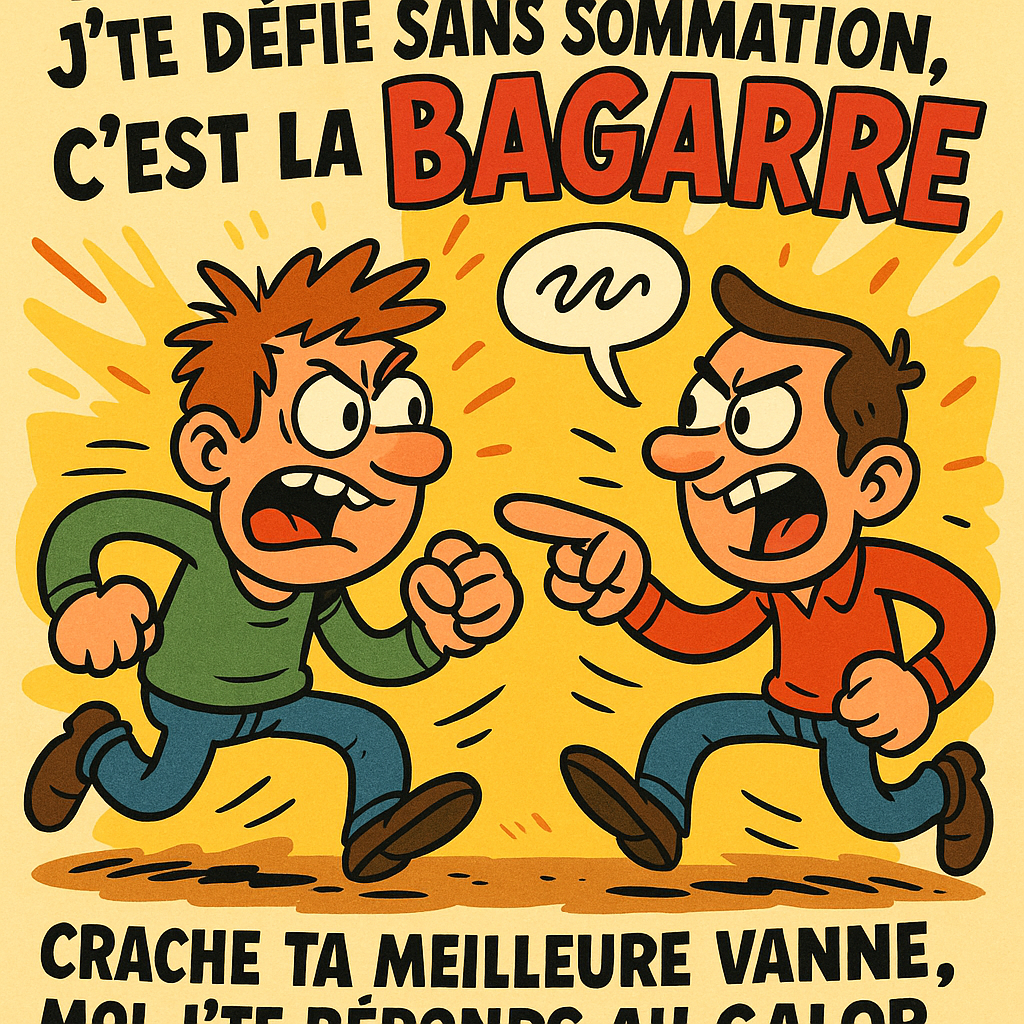

In [11]:
async def run_debate():
    logger.info(f"Contrainte active : {contrainte_choisie[0]}")
    
    group_chat = AgentGroupChat(
        agents=[barbie, ane],
        termination_strategy=DebateTerminationStrategy()
    )
    
    # Add initial topic message (SK requires non-empty chat history)
    await group_chat.add_chat_message(
        ChatMessageContent(role=AuthorRole.USER, content="Commencez le duel verbal !")
    )
    
    async for msg in group_chat.invoke():
        print(f"\n{msg.name}: {msg.content}")
        
        if msg.name == "Ane_Shrek":
            try:
                image_result = await ane.kernel.invoke(
                    function_name="generate_image",
                    plugin_name="image_gen",
                    arguments=KernelArguments(context=msg.content)
                )
                if image_result:
                    import base64
                    from IPython.display import display, Image
                    img_str = str(image_result)
                    if img_str.startswith("http"):
                        display(Image(url=img_str, width=300))
                    else:
                        display(Image(data=base64.b64decode(img_str), width=300))
            except Exception as e:
                logger.warning(f"Image generation skipped: {e}")

await run_debate()

## Conclusion

This notebook made it possible to explore the essential aspects of barbie schreck. Key points:

- The fundamental concepts were presented and illustrated
- The exercises offer progressive hands-on practice
- The results obtained make it possible to validate understanding

**To go further**: delve deeper into the advanced aspects of the subject and explore links with other fields.

### Exercise 3: Custom termination strategy

The current implementation stops the debate after a fixed number of turns (`MAX_TURNS = 5`). Imagine a scenario where the debate must stop dynamically based on the content of the messages.

**Objective**: implement a termination strategy that detects when one of the two characters uses a specific word (for example "capituler" or "abandon") in their response, and stops the debate immediately.

**Hints**:
- # Step 1: Define a list of trigger keywords
- # Step 2: In `should_terminate`, check whether the last message contains a keyword
- # Hint: use `str(history[-1].content).lower()` to read the last message

In [12]:
from typing import ClassVar
from semantic_kernel.agents.strategies.termination.termination_strategy import TerminationStrategy

class SurrenderTerminationStrategy(TerminationStrategy):
    # TODO etudiant : completer la strategy de terminaison par mots-cles
    TRIGGER_WORDS: ClassVar[list[str]] = []  # Etape 1 : mots-cles declencheurs
    
    async def should_terminate(self, agent, history, cancellation_token=None) -> bool:
        # Etape 2 : verifier si le dernier message contient un mot-cle
        result = False  # TODO etudiant : remplacer par la logique de detection
        return result

print("Exercice a completer : SurrenderTerminationStrategy")

Exercice a completer : SurrenderTerminationStrategy
